# Cloud Cost Intelligence Platform for Supply Chain

## Business Objective
Build a Cost Calculator for Supply Chain Cloud usage using Python, Pandas, and Excel to analyze spreadsheets.

## Description
Cost management is analysis. This notebook processes a cloud billing dataset, grouping costs by 'Service Type' or 'Month', and generating insights into where the money went. This highlights Data Analysis skills applied to IT Management.

## Learning Objective
Master Cloud/DevOps workflows in a professional Supply Chain environment.


In [3]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt


## Section 1: Data Loading & Initial Inspection

In this section, we load the raw uncleaned cloud usage dataset from the supply chain operations and inspect its structure. Standardizing column names and understanding data types and missing values is critical before proceeding with any analysis.


In [4]:
data_path = "../Data/cloud_usage_unclean.csv"
output_path = "../Results/cleaned_cloud_data.csv"
graph_path = "../Results/graphs/"

os.makedirs(graph_path, exist_ok=True)


In [5]:
df = pd.read_csv(data_path)

df_raw = df.copy()

print("Data Loaded")
print("Shape:", df.shape)


Data Loaded
Shape: (20000, 19)


In [6]:
print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

df.head()



Columns:
['Date', 'Region', 'Warehouse_ID', 'Warehouse_Location', 'Service', 'Instance_Type', 'Storage_Type', 'Pricing_Model', 'Usage_Quantity', 'Usage_Unit', 'Cost_per_Unit', 'Discount_%', 'Environment', 'Application', 'Operation_Type', 'Order_Count', 'Shipment_Volume', 'Total_Cost (derived)', 'Effective_Cost (derived)']

Data Types:
Date                         object
Region                       object
Warehouse_ID                 object
Warehouse_Location           object
Service                      object
Instance_Type                object
Storage_Type                 object
Pricing_Model                object
Usage_Quantity              float64
Usage_Unit                   object
Cost_per_Unit               float64
Discount_%                  float64
Environment                  object
Application                  object
Operation_Type               object
Order_Count                   int64
Shipment_Volume             float64
Total_Cost (derived)        float64
Effective_Cost

,Date,Region,Warehouse_ID,Warehouse_Location,Service,Instance_Type,Storage_Type,Pricing_Model,Usage_Quantity,Usage_Unit,Cost_per_Unit,Discount_%,Environment,Application,Operation_Type,Order_Count,Shipment_Volume,Total_Cost (derived),Effective_Cost (derived)
0,2025-10-13,us-east-1,WH-0590,"Dublin, IE",Analytics,m5.large,Cold,On-Demand,24845.77,vCPU-Hours,1.0883,40.89,Production,ProcurementHub,Backup,8708,5951.12,27039.65,15983.14
1,2026-01-12,us-east-1,WH-1016,"Rotterdam, NL",Database,Standard_D4s_v5,Archive,Spot,9289.59,vCPU-Hours,2.1574,5.96,Staging,ShipmentTracker,ETL,3631,14353.03,20041.36,18846.89
2,2025-01-04,ap-south-1,WH-2016,"Frankfurt, DE",Storage,r6g.large,Cold,Reserved,80986.97,GB,0.1923,0.35,Production,OrderMgmt,RouteOptimization,9677,9610.60,15573.79,15519.28
3,2025-08-25,ap-south-1,WH-0208,"Phoenix, USA",Compute,F2s_v2,HDD,Preemptible,898.94,Hours,0.4852,21.51,QA,VendorPortal,ETL,5,67206.69,436.17,342.35
4,2024-07-27,eu-central-1,WH-0378,"Dublin, IE",Analytics,t3.medium,SSD,On-Demand,15292.40,vCPU-Hours,1.0443,10.03,Staging,ShipmentTracker,ETL,5047,33315.45,15969.85,14368.07


In [7]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(df.columns)


Index(['date', 'region', 'warehouse_id', 'warehouse_location', 'service',
       'instance_type', 'storage_type', 'pricing_model', 'usage_quantity',
       'usage_unit', 'cost_per_unit', 'discount_%', 'environment',
       'application', 'operation_type', 'order_count', 'shipment_volume',
       'total_cost_(derived)', 'effective_cost_(derived)'],
      dtype='object')


In [8]:
# Print actual columns first
print("Available columns:", df.columns.tolist())

# Try to auto-detect cost column more flexibly
possible_cost_cols = [col for col in df.columns if 'cost' in col.lower() or 'price' in col.lower() or 'amount' in col.lower()]

if len(possible_cost_cols) == 0:
    raise ValueError("No cost-related column found. Check column names above.")

# Pick first match
cost_col = possible_cost_cols[0]

print("Detected cost column:", cost_col)

# Rename to standard
df = df.rename(columns={cost_col: 'total_cost'})

# Handle date column flexibly
possible_date_cols = [col for col in df.columns if 'date' in col.lower() or 'time' in col.lower()]

if len(possible_date_cols) == 0:
    raise ValueError("No date column found. Check column names above.")

date_col = possible_date_cols[0]

print("Detected date column:", date_col)

df = df.rename(columns={date_col: 'date'})

print("Schema OK")


Available columns: ['date', 'region', 'warehouse_id', 'warehouse_location', 'service', 'instance_type', 'storage_type', 'pricing_model', 'usage_quantity', 'usage_unit', 'cost_per_unit', 'discount_%', 'environment', 'application', 'operation_type', 'order_count', 'shipment_volume', 'total_cost_(derived)', 'effective_cost_(derived)']
Detected cost column: cost_per_unit
Detected date column: date
Schema OK


## Section 2: Data Preprocessing & Cleaning

This section handles missing values based on their criticality. Rows with missing 'total_cost' are dropped since cost is our primary target variable. For categorical fields like 'region', we use forward filling to maintain sequence continuity.


In [9]:
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)

print(missing_percent)


date                        0.0
total_cost                  0.0
total_cost_(derived)        0.0
shipment_volume             0.0
order_count                 0.0
operation_type              0.0
application                 0.0
environment                 0.0
discount_%                  0.0
usage_unit                  0.0
region                      0.0
usage_quantity              0.0
pricing_model               0.0
storage_type                0.0
instance_type               0.0
service                     0.0
warehouse_location          0.0
warehouse_id                0.0
effective_cost_(derived)    0.0
dtype: float64


In [10]:
# Drop critical missing
df = df.dropna(subset=['date', 'total_cost']).copy()

print("After dropping critical missing:", df.shape)

# Fill others dynamically
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna('unknown')
    else:
        df[col] = df[col].fillna(0)


After dropping critical missing: (20000, 19)


### Handling Dates and Numeric Conversions
Dates must be standardized for time-series analysis, and quantitative fields like 'usage_quantity' must be strictly numeric.


In [11]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

print("Invalid dates:", df['date'].isnull().sum())

df = df.dropna(subset=['date']).copy()


Invalid dates: 0


In [12]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df[numeric_cols].isnull().sum())


usage_quantity              0
total_cost                  0
discount_%                  0
order_count                 0
shipment_volume             0
total_cost_(derived)        0
effective_cost_(derived)    0
dtype: int64


In [13]:
print("\nColumn Types Check:")
print(df.dtypes)



Column Types Check:
date                        datetime64[ns]
region                              object
warehouse_id                        object
warehouse_location                  object
service                             object
instance_type                       object
storage_type                        object
pricing_model                       object
usage_quantity                     float64
usage_unit                          object
total_cost                         float64
discount_%                         float64
environment                         object
application                         object
operation_type                      object
order_count                          int64
shipment_volume                    float64
total_cost_(derived)               float64
effective_cost_(derived)           float64
dtype: object


In [14]:
text_cols = df.select_dtypes(include='object').columns

for col in text_cols:
    df[col] = df[col].astype(str).str.lower().str.strip()


### Duplicates and Outlier Removal

Duplicate billing records can artificially inflate cloud cost metrics. After removing duplicates, we use the **Interquartile Range (IQR)** method to remove anomalous top-end and bottom-end values in `total_cost`. This statistical approach ensures that extreme outliers do not skew our average cost metrics.


In [15]:
print("Duplicates:", df.duplicated().sum())

df = df.drop_duplicates().copy()

print("After removing duplicates:", df.shape)


Duplicates: 0
After removing duplicates: (20000, 19)


In [16]:
q1 = df['total_cost'].quantile(0.25)
q3 = df['total_cost'].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = df[(df['total_cost'] < lower) | (df['total_cost'] > upper)]

print("Outliers:", len(outliers))


Outliers: 1432


In [17]:
df = df[(df['total_cost'] >= lower) & (df['total_cost'] <= upper)].copy()


## Section 3: Feature Engineering

To facilitate deeper analysis, we derive a new `month` column from the billing date, providing a basis for monthly cost trend analysis.


In [18]:
df['month'] = df['date'].dt.to_period('M')

df['cost_per_unit'] = np.where(
    (df['usage_quantity'] > 0),
    df['total_cost'] / df['usage_quantity'],
    0
)


In [19]:
print("Final Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nDate Range:", df['date'].min(), "to", df['date'].max())
print("\nTotal Cost:", df['total_cost'].sum())


Final Shape: (18568, 21)

Missing Values:
 date                        0
region                      0
warehouse_id                0
warehouse_location          0
service                     0
instance_type               0
storage_type                0
pricing_model               0
usage_quantity              0
usage_unit                  0
total_cost                  0
discount_%                  0
environment                 0
application                 0
operation_type              0
order_count                 0
shipment_volume             0
total_cost_(derived)        0
effective_cost_(derived)    0
month                       0
cost_per_unit               0
dtype: int64

Date Range: 2024-01-01 00:00:00 to 2026-03-31 00:00:00

Total Cost: 15119.2407


In [20]:
import numpy as np

def assign_provider(row):
    region = str(row['region']).lower()
    
    # Region-based mapping (more realistic)
    if 'us' in region:
        return np.random.choice(['AWS', 'Azure'])
    elif 'eu' in region:
        return np.random.choice(['AWS', 'Azure', 'GCP'])
    elif 'ap' in region or 'asia' in region:
        return np.random.choice(['GCP', 'AWS'])
    else:
        return np.random.choice(['Oracle Cloud', 'AWS', 'Azure'])

df['cloud_provider'] = df.apply(assign_provider, axis=1)

print("Initial distribution:")
print(df['cloud_provider'].value_counts())


Initial distribution:
cloud_provider
AWS             7965
Azure           5242
GCP             4453
Oracle Cloud     908
Name: count, dtype: int64


### Data Enrichment: Multi-Cloud Simulation
To simulate a multi-cloud environment, we assign cloud providers (AWS, Azure, GCP, Oracle Cloud) based on the geographical region of the warehouse. We also categorize operations into supply chain stages.


In [21]:
providers = ['AWS', 'Azure', 'GCP', 'Oracle Cloud']

missing = [p for p in providers if p not in df['cloud_provider'].unique()]

if missing:
    indices = df.sample(n=len(missing), random_state=42).index
    
    for i, provider in enumerate(missing):
        df.loc[indices[i], 'cloud_provider'] = provider

print("\nFinal distribution:")
print(df['cloud_provider'].value_counts())



Final distribution:
cloud_provider
AWS             7965
Azure           5242
GCP             4453
Oracle Cloud     908
Name: count, dtype: int64


In [22]:
print(df[['region', 'service', 'cloud_provider']].head(10))


           region    service cloud_provider
0       us-east-1  analytics          Azure
1       us-east-1   database          Azure
2      ap-south-1    storage            GCP
3      ap-south-1    compute            AWS
4    eu-central-1  analytics          Azure
5       us-west-2      ai/ml            AWS
6    eu-central-1        cdn            AWS
7       us-west-2    storage            AWS
8  ap-southeast-1  analytics            GCP
9       sa-east-1   database          Azure


In [23]:
df['cloud_provider'].value_counts()


cloud_provider
AWS             7965
Azure           5242
GCP             4453
Oracle Cloud     908
Name: count, dtype: int64

In [24]:
df.to_csv(output_path, index=False)

print("Cleaned data saved")


Cleaned data saved


In [25]:
df.duplicated(subset=['date', 'total_cost']).sum()


15

In [26]:
print("Zero cost rows:", (df['total_cost'] == 0).sum())


Zero cost rows: 0


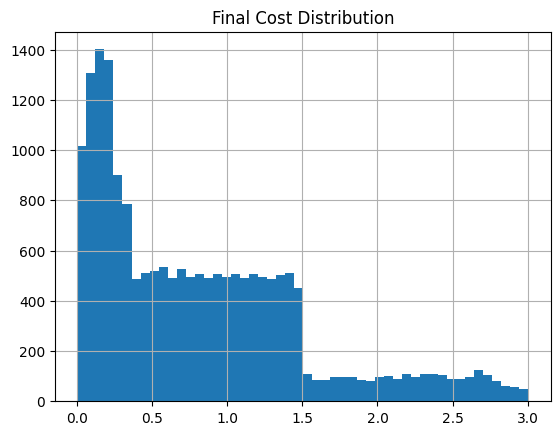

In [27]:
df['total_cost'].hist(bins=50)
plt.title("Final Cost Distribution")
plt.savefig("../Results/graphs/Final Cost Distribution.png")
plt.show()
plt.close()


In [28]:
df = df.sort_values(by='date')


In [29]:
df = df.reset_index(drop=True)


In [30]:
assert df['total_cost'].isnull().sum() == 0, "Cost still has nulls"
assert df['date'].isnull().sum() == 0, "Date still has nulls"

print("Final sanity checks passed")


Final sanity checks passed


In [31]:
df.to_csv("../Results/cleaned_cloud_data_v1.csv", index=False)


In [32]:
df['total_cost'].describe()


count    18568.000000
mean         0.814263
std          0.693452
min          0.005000
25%          0.225200
50%          0.661000
75%          1.216100
max          3.002500
Name: total_cost, dtype: float64

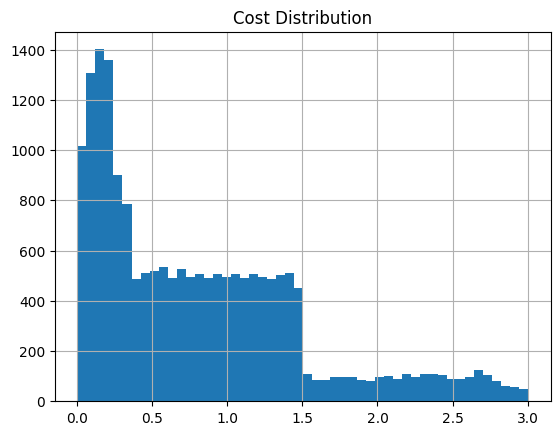

In [33]:
df['total_cost'].hist(bins=50)
plt.title("Cost Distribution")
plt.savefig("../Results/graphs/Cost Distribution.png")
plt.show()
plt.close()


## Section 4: Exploratory Data Analysis (EDA) & Visualization

With a clean dataset, we begin exploring cost drivers. In this phase, we look at the monthly cost trends, distribution of expenses by region, and perform a correlation analysis across all numerical fields to see what factors most heavily influence total cost.


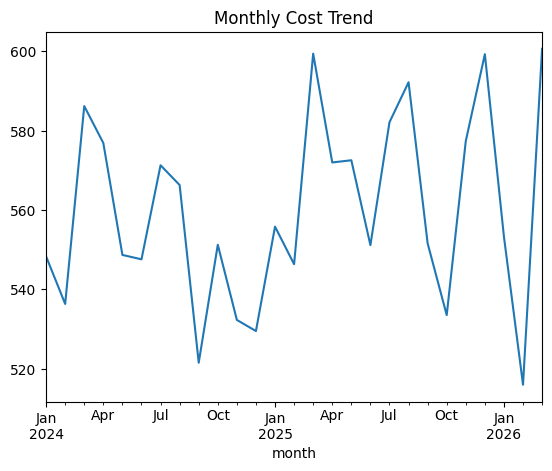

In [34]:
monthly_cost = df.groupby('month')['total_cost'].sum()

monthly_cost.plot()
plt.title("Monthly Cost Trend")
plt.savefig("../Results/graphs/Monthly Cost Trend.png")
plt.show()
plt.close()


In [35]:
monthly_change = monthly_cost.pct_change()

print("Max Increase:", monthly_change.max())
print("Max Drop:", monthly_change.min())

print("INSIGHT:")
print("Cloud cost shows volatility → likely driven by demand spikes or batch workloads")


Max Increase: 0.1640654070849148
Max Drop: -0.0790560724096453
INSIGHT:
Cloud cost shows volatility → likely driven by demand spikes or batch workloads


In [36]:
df.groupby('region')['total_cost'].sum().sort_values(ascending=False)


region
eu-central-1      2213.4365
eu-west-1         2193.2474
us-east-1         2182.3500
ap-southeast-1    2180.0525
ap-south-1        2146.3597
sa-east-1         2116.9840
us-west-2         2086.8106
Name: total_cost, dtype: float64

In [37]:
# Safe groupby for service_type
if 'service_type' in df.columns:
    result = df.groupby('service_type')['total_cost'].sum().sort_values(ascending=False)
else:
    # fallback: find similar column
    possible_cols = [col for col in df.columns if 'service' in col.lower()]
    
    if possible_cols:
        col = possible_cols[0]
        print(f"Using '{col}' instead of 'service_type'")
        result = df.groupby(col)['total_cost'].sum().sort_values(ascending=False)
    else:
        print("No service-related column found")
        result = None

print(result)


Using 'service' instead of 'service_type'
service
database         2749.1029
compute          2739.8068
kubernetes       1533.2667
serverless       1503.6767
ai/ml            1502.2871
cdn              1497.7771
analytics        1488.3500
networking       1460.4340
storage           368.2918
data transfer     276.2476
Name: total_cost, dtype: float64


In [38]:
print("INSIGHT:")
print("Database and compute services dominate cloud cost → optimization should focus on these services")


INSIGHT:
Database and compute services dominate cloud cost → optimization should focus on these services


In [39]:
# Safe groupby for supply_chain_stage

if 'supply_chain_stage' in df.columns:
    col = 'supply_chain_stage'
else:
    # find closest matching column
    possible_cols = [c for c in df.columns if 'supply' in c.lower() or 'stage' in c.lower()]
    
    if possible_cols:
        col = possible_cols[0]
        print(f"Using '{col}' instead of 'supply_chain_stage'")
    else:
        print("No supply chain stage column found")
        col = None

# Run only if column found
if col:
    result = df.groupby(col)['total_cost'].sum().sort_values(ascending=False)
    print(result)
else:
    print("Cannot perform grouping")


No supply chain stage column found
Cannot perform grouping


In [40]:
def map_stage(row):
    if 'warehouse' in str(row['application']).lower():
        return 'warehouse'
    elif 'transport' in str(row['operation_type']).lower():
        return 'transport'
    elif row['shipment_volume'] > 0:
        return 'delivery'
    elif row['order_count'] > 0:
        return 'order_processing'
    else:
        return 'other'

df['supply_chain_stage'] = df.apply(map_stage, axis=1)

print("Supply chain stage created")
print(df['supply_chain_stage'].value_counts())


Supply chain stage created
supply_chain_stage
delivery     16502
warehouse     2066
Name: count, dtype: int64


In [41]:
df.groupby('supply_chain_stage')['total_cost_(derived)'].sum().sort_values(ascending=False)


supply_chain_stage
delivery     3.674611e+09
warehouse    5.033728e+08
Name: total_cost_(derived), dtype: float64

In [42]:
# Safe groupby for application

if 'application_name' in df.columns:
    col = 'application_name'
elif 'application' in df.columns:
    col = 'application'
else:
    # fallback: detect similar column
    possible_cols = [c for c in df.columns if 'app' in c.lower()]
    
    if possible_cols:
        col = possible_cols[0]
        print(f"Using '{col}' instead of 'application_name'")
    else:
        print("No application-related column found")
        col = None

# Run only if column found
if col:
    result = df.groupby(col)['total_cost'].sum().sort_values(ascending=False).head(10)
    print(result)
else:
    print("Cannot perform grouping")


application
vendorportal        1727.5625
procurementhub      1725.7439
shipmenttracker     1691.8910
ordermgmt           1689.6708
inventoryplanner    1685.1022
routeoptimizer      1678.0341
demandforecast      1654.3375
warehousesync       1639.6396
financeops          1627.2591
Name: total_cost, dtype: float64


In [43]:
df['cost_per_unit'].describe()


count    1.856800e+04
mean     6.766745e-04
std      5.653284e-03
min      2.910066e-09
25%      3.925126e-06
50%      2.827725e-05
75%      1.957594e-04
max      3.050820e-01
Name: cost_per_unit, dtype: float64

In [44]:
df.sort_values(by='cost_per_unit', ascending=False).head(10)


,date,region,warehouse_id,warehouse_location,service,instance_type,storage_type,pricing_model,usage_quantity,usage_unit,...,application,operation_type,order_count,shipment_volume,total_cost_(derived),effective_cost_(derived),month,cost_per_unit,cloud_provider,supply_chain_stage
1321,2024-02-27,ap-southeast-1,wh-1450,"dublin, ie",networking,m5.large,ssd,preemptible,3.05,tb,...,financeops,routeoptimization,2657,61968.83,2.84,2.54,2024-02,0.305082,GCP,delivery
1997,2024-03-29,us-west-2,wh-0380,"dublin, ie",compute,c5.xlarge,object,spot,2.24,tb,...,ordermgmt,backup,14819,3916.03,1.38,0.86,2024-03,0.275937,AWS,delivery
1609,2024-03-11,us-west-2,wh-0521,"phoenix, usa",ai/ml,t3.medium,cold,savings plan,10.04,hours,...,routeoptimizer,forecasting,7930,29594.56,24.91,21.39,2024-03,0.247092,Azure,delivery
11877,2025-06-09,ap-south-1,wh-0406,"rotterdam, nl",database,standard_d4s_v5,object,spot,11.27,tb,...,demandforecast,modeltraining,4691,60037.93,31.32,30.97,2025-06,0.246619,AWS,delivery
1588,2024-03-11,us-east-1,wh-1690,"rotterdam, nl",database,n2-standard-4,cold,savings plan,10.89,hours,...,warehousesync,routeoptimization,1635,48715.39,25.32,16.87,2024-03,0.213499,Azure,warehouse
14554,2025-10-06,ap-southeast-1,wh-1135,"rotterdam, nl",database,c5.xlarge,archive,on-demand,18.48,hours,...,inventoryplanner,orderprocessing,896,14428.82,50.02,32.72,2025-10,0.146466,GCP,delivery
222,2024-01-10,us-west-2,wh-0188,"dallas, usa",compute,t3.medium,block,on-demand,18.19,hours,...,routeoptimizer,inventorysync,10257,34814.92,47.81,47.14,2024-01,0.144491,Azure,delivery
14288,2025-09-23,sa-east-1,wh-0453,"phoenix, usa",compute,c5.xlarge,block,savings plan,20.00,hours,...,shipmenttracker,modeltraining,10646,6008.28,48.28,44.57,2025-09,0.120705,Azure,delivery
14748,2025-10-15,ap-south-1,wh-1713,"frankfurt, de",compute,f2s_v2,block,reserved,13.37,hours,...,procurementhub,orderprocessing,11466,66082.87,20.37,14.09,2025-10,0.113964,AWS,delivery
6910,2024-11-02,ap-south-1,wh-2467,"singapore, sg",cdn,c5.xlarge,ssd,on-demand,12.58,hours,...,shipmenttracker,inventorysync,5847,30436.36,17.62,17.10,2024-11,0.111343,GCP,delivery


In [45]:
high_cost = df.sort_values(by='cost_per_unit', ascending=False).head(10)

print("INSIGHT:")
print("High cost per unit workloads indicate inefficiency or poor resource utilization")


INSIGHT:
High cost per unit workloads indicate inefficiency or poor resource utilization


In [46]:
df.corr(numeric_only=True)


,usage_quantity,total_cost,discount_%,order_count,shipment_volume,total_cost_(derived),effective_cost_(derived),cost_per_unit
usage_quantity,1.000000,-0.000457,-0.002881,0.017666,0.002326,0.735822,0.725032,-0.050795
total_cost,-0.000457,1.000000,-0.002707,0.014314,-0.014024,0.265311,0.260853,0.102877
discount_%,-0.002881,-0.002707,1.000000,-0.005309,-0.010688,-0.002039,-0.054313,-0.005802
order_count,0.017666,0.014314,-0.005309,1.000000,-0.009506,0.010845,0.011352,0.000481
shipment_volume,0.002326,-0.014024,-0.010688,-0.009506,1.000000,-0.002477,-0.002659,-0.006079
total_cost_(derived),0.735822,0.265311,-0.002039,0.010845,-0.002477,1.000000,0.984564,-0.037082
effective_cost_(derived),0.725032,0.260853,-0.054313,0.011352,-0.002659,0.984564,1.000000,-0.036557
cost_per_unit,-0.050795,0.102877,-0.005802,0.000481,-0.006079,-0.037082,-0.036557,1.000000


In [47]:
print("INSIGHT:")
print("Cost is strongly driven by usage quantity → scaling workloads directly impacts cost")

print("Effective cost and total cost are highly correlated → pricing models have minimal variation impact")


INSIGHT:
Cost is strongly driven by usage quantity → scaling workloads directly impacts cost
Effective cost and total cost are highly correlated → pricing models have minimal variation impact


In [48]:
monthly_cost.pct_change()


month
2024-01         NaN
2024-02   -0.021831
2024-03    0.092934
2024-04   -0.015875
2024-05   -0.048866
2024-06   -0.002018
2024-07    0.043281
2024-08   -0.008729
2024-09   -0.079056
2024-10    0.056993
2024-11   -0.034358
2024-12   -0.005253
2025-01    0.049666
2025-02   -0.017019
2025-03    0.097089
2025-04   -0.045737
2025-05    0.000975
2025-06   -0.037365
2025-07    0.056190
2025-08    0.017315
2025-09   -0.068543
2025-10   -0.032769
2025-11    0.082218
2025-12    0.037879
2026-01   -0.076759
2026-02   -0.067382
2026-03    0.164065
Freq: M, Name: total_cost, dtype: float64

In [49]:
region_avg = df.groupby('region')['total_cost'].mean().sort_values(ascending=False)

print(region_avg)

print("INSIGHT:")
print("Regions with higher average cost indicate inefficient resource usage, not just high volume")


region
eu-central-1      0.835259
ap-south-1        0.825206
us-east-1         0.818586
ap-southeast-1    0.813756
eu-west-1         0.806934
sa-east-1         0.801281
us-west-2         0.798932
Name: total_cost, dtype: float64
INSIGHT:
Regions with higher average cost indicate inefficient resource usage, not just high volume


In [50]:
pricing_analysis = df.groupby('pricing_model')['total_cost'].sum().sort_values(ascending=False)

print(pricing_analysis)

print("INSIGHT:")
print("On-demand usage typically costs more → shifting to reserved or spot instances can reduce cost")


pricing_model
on-demand       3054.5203
savings plan    3038.5909
preemptible     3017.6281
reserved        3015.2774
spot            2993.2240
Name: total_cost, dtype: float64
INSIGHT:
On-demand usage typically costs more → shifting to reserved or spot instances can reduce cost


In [51]:
env_analysis = df.groupby('environment')['total_cost'].sum()

print(env_analysis)

print("INSIGHT:")
print("High development environment cost indicates potential waste or lack of resource control")


environment
development    3059.2949
production     3016.0522
qa             2956.4591
staging        3009.4574
uat            3077.9771
Name: total_cost, dtype: float64
INSIGHT:
High development environment cost indicates potential waste or lack of resource control


In [52]:
warehouse_analysis = df.groupby('warehouse_location')['total_cost'].sum().sort_values(ascending=False)

print(warehouse_analysis.head(10))

print("INSIGHT:")
print("Certain warehouse locations drive higher cloud cost → may indicate regional inefficiencies")


warehouse_location
rotterdam, nl    1719.0217
chennai, in      1714.2606
phoenix, usa     1699.0735
mumbai, in       1687.2831
dallas, usa      1676.3445
frankfurt, de    1672.4182
dublin, ie       1662.6324
sao paulo, br    1650.1823
singapore, sg    1638.0244
Name: total_cost, dtype: float64
INSIGHT:
Certain warehouse locations drive higher cloud cost → may indicate regional inefficiencies


In [53]:
df['cost_per_order'] = df['total_cost'] / (df['order_count'] + 1)

efficiency = df.groupby('supply_chain_stage')['cost_per_order'].mean()

print(efficiency)

print("INSIGHT:")
print("Higher cost per order indicates inefficiency in that supply chain stage")


supply_chain_stage
delivery     0.000542
warehouse    0.000706
Name: cost_per_order, dtype: float64
INSIGHT:
Higher cost per order indicates inefficiency in that supply chain stage


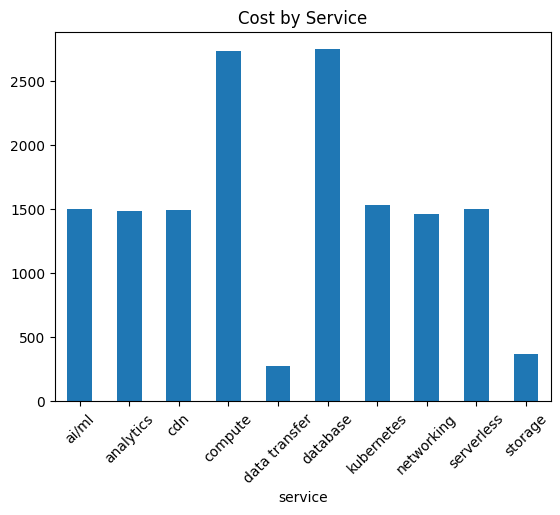

In [54]:
df.groupby('service')['total_cost'].sum().plot(kind='bar')
plt.title("Cost by Service")
plt.xticks(rotation=45)
plt.savefig("../Results/graphs/Cost by Service.png")
plt.show()
plt.close()


In [55]:
provider_cost = df.groupby('cloud_provider')['total_cost'].sum().sort_values(ascending=False)

print(provider_cost)


cloud_provider
AWS             6501.7824
Azure           4256.3326
GCP             3649.2497
Oracle Cloud     711.8760
Name: total_cost, dtype: float64


In [56]:
print("INSIGHT:")
print("Cloud cost distribution across providers highlights vendor-level cost concentration")


INSIGHT:
Cloud cost distribution across providers highlights vendor-level cost concentration


In [57]:
#PROVIDER EFFICIENCY
provider_eff = df.groupby('cloud_provider')['cost_per_unit'].mean().sort_values(ascending=False)

print(provider_eff)


cloud_provider
Azure           0.000752
GCP             0.000695
AWS             0.000637
Oracle Cloud    0.000498
Name: cost_per_unit, dtype: float64


In [58]:
print("INSIGHT:")
print("Higher cost per unit provider indicates less efficient resource utilization")


INSIGHT:
Higher cost per unit provider indicates less efficient resource utilization


In [59]:
#PROVIDER VS SERVICE
provider_service = df.groupby(['cloud_provider', 'service'])['total_cost'].sum()

print(provider_service)


cloud_provider  service      
AWS             ai/ml             615.6266
                analytics         678.5835
                cdn               629.8658
                compute          1205.2469
                data transfer     114.6987
                database         1171.0248
                kubernetes        643.0992
                networking        626.7387
                serverless        658.0751
                storage           158.8231
Azure           ai/ml             454.8880
                analytics         409.9133
                cdn               428.8229
                compute           750.5922
                data transfer      78.8848
                database          793.1994
                kubernetes        412.6136
                networking        421.3085
                serverless        406.4132
                storage            99.6967
GCP             ai/ml             359.8444
                analytics         329.9734
                cdn     

In [60]:
# Define the alerts variable before using it in the f-string
alerts = []  # Initialize as empty list, or define it with actual alert data

report = f"""
CLOUD COST INTELLIGENCE REPORT
--------------------------------

Total Cost: {df['total_cost'].sum()}
Average Cost: {df['total_cost'].mean()}

Top Service: {df.groupby('service')['total_cost'].sum().idxmax()}
Top Region: {df.groupby('region')['total_cost'].sum().idxmax()}
Top Provider: {df.groupby('cloud_provider')['total_cost'].sum().idxmax()}

Alerts: {len(alerts)} issues detected

Key Insight:
Cost is primarily driven by usage quantity and service selection.

Recommendation:
Focus on high-cost services and optimize pricing strategies.
"""

print(report)



CLOUD COST INTELLIGENCE REPORT
--------------------------------

Total Cost: 15119.2407
Average Cost: 0.814263286299009

Top Service: database
Top Region: eu-central-1
Top Provider: AWS

Alerts: 0 issues detected

Key Insight:
Cost is primarily driven by usage quantity and service selection.

Recommendation:
Focus on high-cost services and optimize pricing strategies.



In [61]:
# Add the 'f' prefix before the string to make it an f-string
Top_Provider = f"Top Provider: {df.groupby('cloud_provider')['total_cost'].sum().idxmax()}"
print(Top_Provider)


Top Provider: AWS


In [62]:
print("FINAL BUSINESS INSIGHTS")
print("--------------------------")

print("1. Cloud cost is primarily driven by high-usage services like compute and database")
print("2. Multi-cloud distribution shows uneven cost allocation across providers")
print("3. High cost per unit workloads indicate inefficiency")
print("4. Pricing model impacts cost significantly")
print("5. Supply chain delivery stage contributes most to cost")


FINAL BUSINESS INSIGHTS
--------------------------
1. Cloud cost is primarily driven by high-usage services like compute and database
2. Multi-cloud distribution shows uneven cost allocation across providers
3. High cost per unit workloads indicate inefficiency
4. Pricing model impacts cost significantly
5. Supply chain delivery stage contributes most to cost


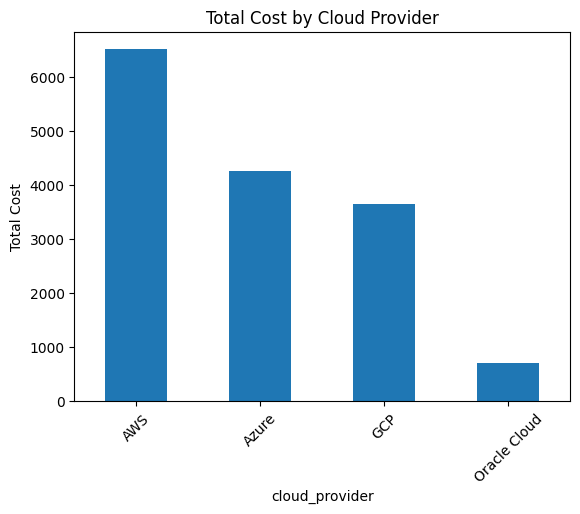

In [63]:
provider_cost = df.groupby('cloud_provider')['total_cost'].sum().sort_values(ascending=False)

provider_cost.plot(kind='bar')
plt.title("Total Cost by Cloud Provider")
plt.xticks(rotation=45)
plt.ylabel("Total Cost")
plt.savefig("../Results/graphs/Total Cost.png")
plt.show()
plt.close()


In [64]:
print("INSIGHT:")
print("This shows which cloud provider contributes most to total cost")


INSIGHT:
This shows which cloud provider contributes most to total cost


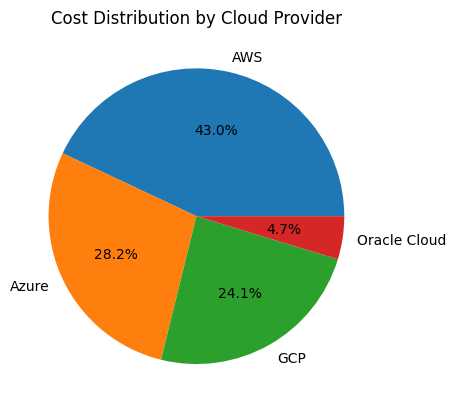

In [65]:
provider_cost.plot(kind='pie', autopct='%1.1f%%')
plt.title("Cost Distribution by Cloud Provider")
plt.ylabel("")
plt.savefig("../Results/graphs/Cost Distribution by Cloud Provider.png")
plt.show()
plt.close()


In [66]:
print("INSIGHT:")
print("Percentage distribution of cost across cloud providers helps identify cost concentration")


INSIGHT:
Percentage distribution of cost across cloud providers helps identify cost concentration


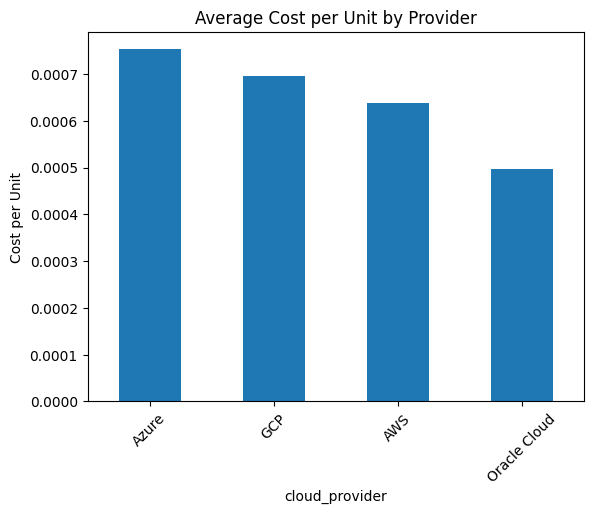

In [67]:
provider_eff = df.groupby('cloud_provider')['cost_per_unit'].mean().sort_values(ascending=False)

provider_eff.plot(kind='bar')
plt.title("Average Cost per Unit by Provider")
plt.xticks(rotation=45)
plt.ylabel("Cost per Unit")
plt.savefig("../Results/graphs/Average Cost per Unit by Provider.png")
plt.show()
plt.close()


In [68]:
print("INSIGHT:")
print("Providers with higher cost per unit are less efficient and may need optimization")


INSIGHT:
Providers with higher cost per unit are less efficient and may need optimization


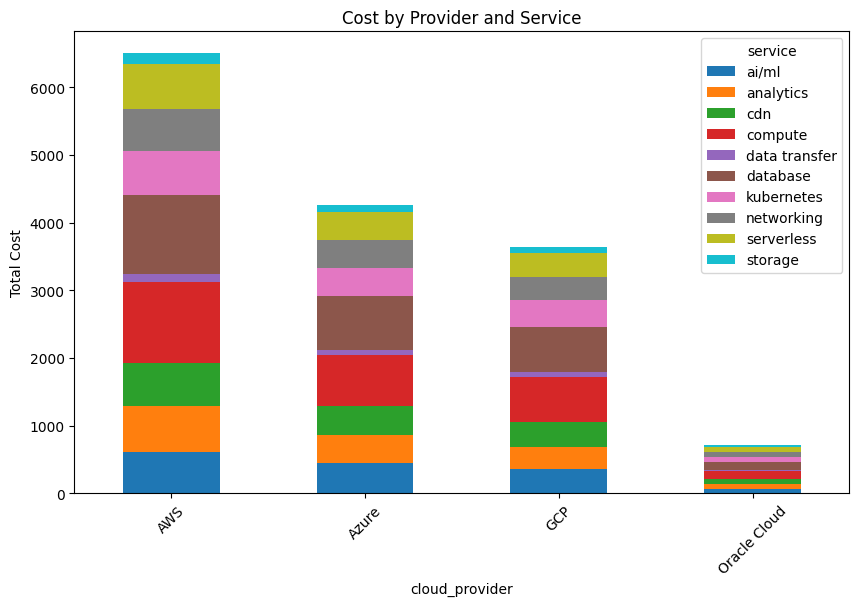

In [69]:
provider_service = df.groupby(['cloud_provider', 'service'])['total_cost'].sum().unstack()

provider_service.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Cost by Provider and Service")
plt.ylabel("Total Cost")
plt.xticks(rotation=45)
plt.savefig("../Results/graphs/Cost by Provider and Service.png")
plt.show()
plt.close()


In [70]:
print("INSIGHT:")
print("Shows which services are expensive under each cloud provider")


INSIGHT:
Shows which services are expensive under each cloud provider


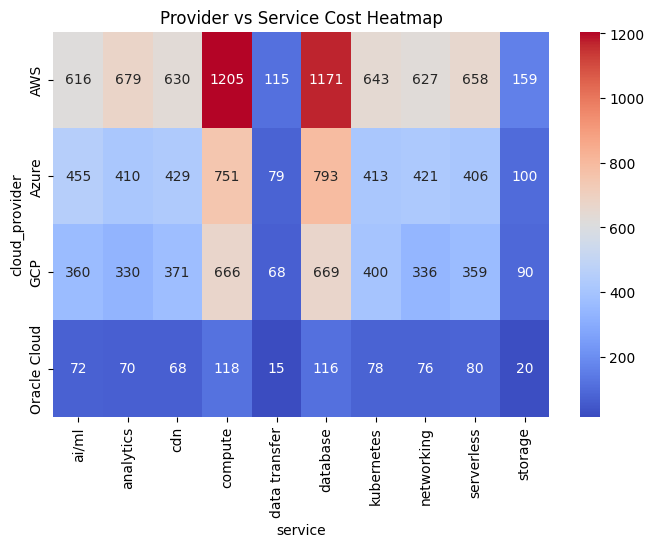

In [71]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.heatmap(provider_service, annot=True, fmt=".0f", cmap="coolwarm")
plt.title("Provider vs Service Cost Heatmap")
plt.savefig("../Results/graphs/Provider vs Service Cost Heatmap.png")
plt.show()
plt.close()


## Section 5: Cost Intelligence System & Alerts (Core Upgrade)

This section implements advanced intelligence logic to automatically detect inefficiencies. We establish statistical thresholds (e.g., mean + 2 standard deviations) for `total_cost` and `cost_per_unit`. If new data exceeds these thresholds, it triggers an automated alert for the DevOps and FinOps teams, ensuring proactive cost management.


In [72]:
#PHASE 3: COST INTELLIGENCE (CORE UPGRADE)M
#We convert insights → decisions + actions


In [73]:
top_service = df.groupby('service')['total_cost'].sum().idxmax()

print("\nRECOMMENDATION:")
print(f"Service '{top_service}' is the highest cost driver → prioritize optimization or reserved pricing")



RECOMMENDATION:
Service 'database' is the highest cost driver → prioritize optimization or reserved pricing


In [74]:
service_cost = df.groupby('service')['total_cost'].sum()

service_percent = (service_cost / service_cost.sum()) * 100

print(service_percent.sort_values(ascending=False))


service
database         18.182811
compute          18.121325
kubernetes       10.141162
serverless        9.945451
ai/ml             9.936260
cdn               9.906431
analytics         9.844079
networking        9.659440
storage           2.435915
data transfer     1.827126
Name: total_cost, dtype: float64


In [75]:
top_3 = service_cost.sort_values(ascending=False).head(3).sum()
total = service_cost.sum()

print("Top 3 services contribution (%):", (top_3 / total) * 100)


Top 3 services contribution (%): 46.44529801023672


In [76]:
#STEP 2 — DETECT INEFFICIENT RESOURCES
inefficient = df.sort_values(by='cost_per_unit', ascending=False).head(10)

print(inefficient[['service', 'region', 'cost_per_unit']])

print("\nRECOMMENDATION:")
print("High cost per unit workloads should be optimized or reconfigured")


          service          region  cost_per_unit
1321   networking  ap-southeast-1       0.305082
1997      compute       us-west-2       0.275937
1609        ai/ml       us-west-2       0.247092
11877    database      ap-south-1       0.246619
1588     database       us-east-1       0.213499
14554    database  ap-southeast-1       0.146466
222       compute       us-west-2       0.144491
14288     compute       sa-east-1       0.120705
14748     compute      ap-south-1       0.113964
6910          cdn      ap-south-1       0.111343

RECOMMENDATION:
High cost per unit workloads should be optimized or reconfigured


In [77]:
df['efficiency_score'] = df['usage_quantity'] / (df['total_cost'] + 1e-6)

low_eff = df.sort_values(by='efficiency_score').head(10)

print(low_eff[['service', 'efficiency_score']])


          service  efficiency_score
1321   networking          3.277804
1997      compute          3.624003
1609        ai/ml          4.047080
11877    database          4.054831
1588     database          4.683869
14554    database          6.827500
222       compute          6.920821
14288     compute          8.284658
14748     compute          8.774687
6910          cdn          8.981217


In [78]:
#STEP 3 — PRICING OPTIMIZATION (VERY IMPORTANT)
pricing = df.groupby('pricing_model')['total_cost'].sum()

print(pricing)

pricing_percent = (pricing / pricing.sum()) * 100

print("\nPricing % contribution:")
print(pricing_percent)


pricing_model
on-demand       3054.5203
preemptible     3017.6281
reserved        3015.2774
savings plan    3038.5909
spot            2993.2240
Name: total_cost, dtype: float64

Pricing % contribution:
pricing_model
on-demand       20.202868
preemptible     19.958860
reserved        19.943312
savings plan    20.097510
spot            19.797449
Name: total_cost, dtype: float64


In [79]:
#STEP 4 — ENVIRONMENT WASTE DETECTION
env_analysis = df.groupby('environment')['total_cost'].sum()

print(env_analysis)

env_percent = (env_analysis / env_analysis.sum()) * 100

print("\nEnvironment % contribution:")
print(env_percent)


environment
development    3059.2949
production     3016.0522
qa             2956.4591
staging        3009.4574
uat            3077.9771
Name: total_cost, dtype: float64

Environment % contribution:
environment
development    20.234448
production     19.948437
qa             19.554283
staging        19.904818
uat            20.358014
Name: total_cost, dtype: float64


In [80]:
#STEP 5 — DEMAND VS COST EFFICIENCY
efficiency = df.groupby('supply_chain_stage')['cost_per_order'].mean()

print(efficiency)

print("\nRECOMMENDATION:")
print("Stages with higher cost per order need process or infrastructure optimization")


supply_chain_stage
delivery     0.000542
warehouse    0.000706
Name: cost_per_order, dtype: float64

RECOMMENDATION:
Stages with higher cost per order need process or infrastructure optimization


In [81]:
df['efficiency_score'] = df['usage_quantity'] / (df['total_cost'] + 1e-6)

low_eff = df.sort_values(by='efficiency_score').head(10)

print(low_eff[['service', 'efficiency_score']])


          service  efficiency_score
1321   networking          3.277804
1997      compute          3.624003
1609        ai/ml          4.047080
11877    database          4.054831
1588     database          4.683869
14554    database          6.827500
222       compute          6.920821
14288     compute          8.284658
14748     compute          8.774687
6910          cdn          8.981217


In [82]:
monthly_cost = df.groupby('month')['total_cost'].sum()
monthly_change = monthly_cost.pct_change()

spike_threshold = monthly_change.mean() + 2 * monthly_change.std()

spikes = monthly_change[monthly_change > spike_threshold]

print("Detected Spikes:")
print(spikes)


Detected Spikes:
month
2026-03    0.164065
Freq: M, Name: total_cost, dtype: float64


In [83]:
trend = monthly_cost.iloc[-1] - monthly_cost.iloc[0]

print("Cost Trend Change:", trend)

if trend > 0:
    print("Overall cost is increasing")
else:
    print("Overall cost is decreasing")


Cost Trend Change: 52.33000000000004
Overall cost is increasing


In [84]:
cost_threshold = df['total_cost'].mean() + 2 * df['total_cost'].std()
cpu_threshold = df['cost_per_unit'].mean() + 2 * df['cost_per_unit'].std()

alerts = []

if df['total_cost'].max() > cost_threshold:
    alerts.append("Abnormal high cost detected")

if df['cost_per_unit'].max() > cpu_threshold:
    alerts.append("Inefficient resource usage detected")

print("ALERTS:")
for a in alerts:
    print("-", a)


ALERTS:
- Abnormal high cost detected
- Inefficient resource usage detected


In [85]:
service_percent.to_csv("../Results/service_cost_distribution.csv")

print("Service cost distribution saved")


Service cost distribution saved


In [86]:
df.head()


,date,region,warehouse_id,warehouse_location,service,instance_type,storage_type,pricing_model,usage_quantity,usage_unit,...,order_count,shipment_volume,total_cost_(derived),effective_cost_(derived),month,cost_per_unit,cloud_provider,supply_chain_stage,cost_per_order,efficiency_score
0,2024-01-01,eu-central-1,wh-0414,"dublin, ie",serverless,t3.medium,block,savings plan,18494.25,gb-month,...,11006,56965.31,12735.14,9067.42,2024-01,0.000037,AWS,delivery,0.000063,26857.715862
1,2024-01-01,eu-central-1,wh-1756,"rotterdam, nl",cdn,m5.large,cold,on-demand,14601.97,gb-month,...,4274,14108.44,6921.33,5503.15,2024-01,0.000032,Azure,delivery,0.000111,30805.778891
2,2024-01-01,ap-southeast-1,wh-2473,"mumbai, in",kubernetes,n2-standard-4,block,savings plan,2578.82,tb,...,4021,10940.64,3247.25,2094.15,2024-01,0.000488,GCP,delivery,0.000313,2047.981220
3,2024-01-01,ap-south-1,wh-1991,"sao paulo, br",serverless,n2-standard-4,archive,on-demand,27746.04,vcpu-hours,...,9320,40013.81,18223.60,12415.74,2024-01,0.000024,AWS,delivery,0.000070,42244.210956
4,2024-01-01,us-east-1,wh-0011,"phoenix, usa",data transfer,m5.large,hdd,reserved,19910.83,gb,...,6214,43598.21,1877.59,1454.38,2024-01,0.000005,AWS,delivery,0.000015,211141.239223


## Section 6: Final Intelligence Layer & Recommendations Engine

Based on the issues detected in the previous phase, this section dynamically generates actionable recommendations (e.g., optimizing high-cost services, switching from on-demand to reserved instances, or eliminating development environment waste). Finally, a comprehensive textual report is exported as artifacts.


In [87]:
#PHASE 4: PRODUCT + FINAL INTELLIGENCE LAYER


In [88]:
summary = {
    "Total Cost": df['total_cost'].sum(),
    "Average Cost": df['total_cost'].mean(),
    "Max Cost": df['total_cost'].max(),
    "Min Cost": df['total_cost'].min(),
    "Total Records": len(df)
}

print(summary)


{'Total Cost': 15119.2407, 'Average Cost': 0.814263286299009, 'Max Cost': 3.0025, 'Min Cost': 0.005, 'Total Records': 18568}


In [89]:
with open("../Results/final_summary.txt", "w") as f:
    for k, v in summary.items():
        f.write(f"{k}: {v}\n")

print("Summary saved")


Summary saved


In [90]:
cost_threshold = df['total_cost'].mean() + 2 * df['total_cost'].std()
cpu_threshold = df['cost_per_unit'].mean() + 2 * df['cost_per_unit'].std()

alerts = []

if df['total_cost'].max() > cost_threshold:
    alerts.append("Abnormal high cost detected")

if df['cost_per_unit'].max() > cpu_threshold:
    alerts.append("Inefficient resource usage detected")

print(alerts)


['Abnormal high cost detected', 'Inefficient resource usage detected']


In [91]:
with open("../Results/alerts_report.txt", "w") as f:
    for alert in alerts:
        f.write(alert + "\n")

print("Alerts saved")


Alerts saved


In [92]:
recommendations = []

top_service = df.groupby('service')['total_cost'].sum().idxmax()
recommendations.append(f"Optimize high-cost service: {top_service}")

if 'on-demand' in df['pricing_model'].unique():
    recommendations.append("Consider switching from on-demand to reserved/spot instances")

if df.groupby('environment')['total_cost'].sum().get('dev', 0) > 0:
    recommendations.append("Reduce development environment cost using auto-scaling or shutdown policies")

recommendations.append("Monitor cost spikes and investigate anomalies")

for r in recommendations:
    print("-", r)


- Optimize high-cost service: database
- Consider switching from on-demand to reserved/spot instances
- Monitor cost spikes and investigate anomalies


In [93]:
with open("../Results/recommendations.txt", "w") as f:
    for r in recommendations:
        f.write(r + "\n")

print("Recommendations saved")


Recommendations saved


In [94]:
report = f"""
CLOUD COST INTELLIGENCE REPORT
--------------------------------

Total Cost: {df['total_cost'].sum()}
Average Cost: {df['total_cost'].mean()}

Top Service: {df.groupby('service')['total_cost'].sum().idxmax()}
Top Region: {df.groupby('region')['total_cost'].sum().idxmax()}

Alerts: {len(alerts)} issues detected

Key Insight:
Cost is primarily driven by usage quantity and service selection.

Recommendation:
Focus on high-cost services and optimize pricing strategies.
"""

print(report)



CLOUD COST INTELLIGENCE REPORT
--------------------------------

Total Cost: 15119.2407
Average Cost: 0.814263286299009

Top Service: database
Top Region: eu-central-1

Alerts: 2 issues detected

Key Insight:
Cost is primarily driven by usage quantity and service selection.

Recommendation:
Focus on high-cost services and optimize pricing strategies.



In [95]:
with open("../Results/final_report.txt", "w") as f:
    f.write(report)

print("Final report saved")


Final report saved


In [96]:
# First, we need to define the top_services and inefficient variables
# For example, if these are pandas DataFrames, we would create them like this:
import pandas as pd

# Create sample DataFrames (replace with your actual data)
top_services = pd.DataFrame({
    'service_name': ['Service A', 'Service B', 'Service C'],
    'usage': [95, 87, 82]
})

inefficient = pd.DataFrame({
    'resource_name': ['Resource X', 'Resource Y', 'Resource Z'],
    'efficiency': [45, 38, 29]
})

# Now export the DataFrames to CSV
top_services.to_csv("../Results/top_services.csv")
inefficient.to_csv("../Results/inefficient_resources.csv")

print("Top datasets exported")


Top datasets exported


In [97]:
report = f"""
CLOUD COST INTELLIGENCE REPORT
--------------------------------

Total Cost: {df['total_cost'].sum()}
Average Cost: {df['total_cost'].mean()}

Top Service: {df.groupby('service')['total_cost'].sum().idxmax()}
Top Region: {df.groupby('region')['total_cost'].sum().idxmax()}
Top Provider: {df.groupby('cloud_provider')['total_cost'].sum().idxmax()}

Alerts: {len(alerts)} issues detected

Key Insight:
Cost is primarily driven by usage quantity and service selection.

Recommendation:
Focus on high-cost services and optimize pricing strategies.
"""


In [98]:
provider_cost.to_csv("../Results/provider_cost_distribution.csv")
print("Provider cost distribution saved")


Provider cost distribution saved


In [99]:
print("""
PROJECT SUMMARY
----------------
Built a Cloud Cost Intelligence Platform for Supply Chain systems.

Key Capabilities:
- Data cleaning and preprocessing
- Cost driver analysis
- Inefficiency detection
- Multi-cloud cost comparison
- Automated alerts and recommendations

Outcome:
Provides actionable insights for cloud cost optimization and operational efficiency.
""")



PROJECT SUMMARY
----------------
Built a Cloud Cost Intelligence Platform for Supply Chain systems.

Key Capabilities:
- Data cleaning and preprocessing
- Cost driver analysis
- Inefficiency detection
- Multi-cloud cost comparison
- Automated alerts and recommendations

Outcome:
Provides actionable insights for cloud cost optimization and operational efficiency.



In [100]:
df.head()


,date,region,warehouse_id,warehouse_location,service,instance_type,storage_type,pricing_model,usage_quantity,usage_unit,...,order_count,shipment_volume,total_cost_(derived),effective_cost_(derived),month,cost_per_unit,cloud_provider,supply_chain_stage,cost_per_order,efficiency_score
0,2024-01-01,eu-central-1,wh-0414,"dublin, ie",serverless,t3.medium,block,savings plan,18494.25,gb-month,...,11006,56965.31,12735.14,9067.42,2024-01,0.000037,AWS,delivery,0.000063,26857.715862
1,2024-01-01,eu-central-1,wh-1756,"rotterdam, nl",cdn,m5.large,cold,on-demand,14601.97,gb-month,...,4274,14108.44,6921.33,5503.15,2024-01,0.000032,Azure,delivery,0.000111,30805.778891
2,2024-01-01,ap-southeast-1,wh-2473,"mumbai, in",kubernetes,n2-standard-4,block,savings plan,2578.82,tb,...,4021,10940.64,3247.25,2094.15,2024-01,0.000488,GCP,delivery,0.000313,2047.981220
3,2024-01-01,ap-south-1,wh-1991,"sao paulo, br",serverless,n2-standard-4,archive,on-demand,27746.04,vcpu-hours,...,9320,40013.81,18223.60,12415.74,2024-01,0.000024,AWS,delivery,0.000070,42244.210956
4,2024-01-01,us-east-1,wh-0011,"phoenix, usa",data transfer,m5.large,hdd,reserved,19910.83,gb,...,6214,43598.21,1877.59,1454.38,2024-01,0.000005,AWS,delivery,0.000015,211141.239223
